# Image classification

Oskar Jonsson
20021113-8375

LLM Usage:

In [45]:
%pip install -q numpy matplotlib seaborn 
%pip install -q tensorflow keras
%pip install -q scikit-learn
%pip install -q pandas datetime


import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd
from datetime import datetime
import time
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
def normalize_mnist():
    """
    Download MNIST dataset and normalize using min-max scaling to [0,1].
    """
    (x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
    
    print(f"MNIST - Train shape: {x_train.shape}, Test shape: {x_test.shape}")
    print(f"Original pixel range: [{x_train.min()}, {x_train.max()}]")
    
    # Min-max normalization to [0, 1]
    # Formula: (x - min) / (max - min)
    # For MNIST, min=0, max=255, so this simplifies to x/255.0
    x_train_normalized = x_train.astype('float32') / 255.0
    x_test_normalized = x_test.astype('float32') / 255.0
    
    print(f"Normalized pixel range: [{x_train_normalized.min():.2f}, {x_train_normalized.max():.2f}]")
    
    return (x_train_normalized, y_train), (x_test_normalized, y_test)
    
def normalize_cifar10():
    """
    Download CIFAR-10 dataset and normalize using Z-score normalization.
    """
    
    (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
    
    print(f"CIFAR-10 - Train shape: {x_train.shape}, Test shape: {x_test.shape}")
    print(f"Original pixel range: [{x_train.min()}, {x_train.max()}]")
    print(f"Original mean: {x_train.mean():.3f}, std: {x_train.std():.3f}")
    
    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')
    
    # Calculate mean and std from training data
    # For Z-score normalization: (x - mean) / std
    mean = x_train.mean()
    std = x_train.std()
    
    x_train_normalized = (x_train - mean) / std
    x_test_normalized = (x_test - mean) / std
    
    print(f"Train data - mean: {x_train_normalized.mean():.6f}, std: {x_train_normalized.std():.6f}")
    print(f"Test data - mean: {x_test_normalized.mean():.6f}, std: {x_test_normalized.std():.6f}")
    print(f"Train data - min: {x_train_normalized.min():.3f}, max: {x_train_normalized.max():.3f}")
    print(f"Test data - min: {x_test_normalized.min():.3f}, max: {x_test_normalized.max():.3f}")
    return (x_train_normalized, y_train), (x_test_normalized, y_test)

normalize_mnist()
normalize_cifar10()

MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093


((array([[[[-0.9619245 , -0.91515917, -0.8995707 ],
           [-1.2113398 , -1.1645745 , -1.1801629 ],
           [-1.1022207 , -1.1333976 , -1.2113398 ],
           ...,
           [ 0.58133286,  0.17603296, -0.19809005],
           [ 0.48780212,  0.06691375, -0.2916208 ],
           [ 0.4254483 ,  0.05132529, -0.27603233]],
  
          [[-1.6322283 , -1.5698744 , -1.5698744 ],
           [-1.8816435 , -1.8816435 , -1.8816435 ],
           [-1.6010513 , -1.756936  , -1.8816435 ],
           ...,
           [ 0.03573683, -0.5098592 , -1.0242784 ],
           [-0.026617  , -0.5878015 , -1.1022207 ],
           [ 0.02014837, -0.52544767, -0.9931014 ]],
  
          [[-1.4919322 , -1.5075206 , -1.554286  ],
           [-1.6322283 , -1.7725244 , -1.8816435 ],
           [-1.117809  , -1.4607552 , -1.756936  ],
           ...,
           [-0.04220546, -0.57221305, -1.1022207 ],
           [-0.01102854, -0.57221305, -1.1022207 ],
           [-0.18250158, -0.7436861 , -1.2269284 ]],
  
    

In [18]:
class MNIST_CNN:
    """
    CNN for MNIST.
    - Conv(16-64 filters) + BatchNorm + ReLU
    - MaxPool(2x2)
    - Conv(32-128 filters) + BatchNorm + ReLU
    - MaxPool(2x2)
    - Flatten + Dense(128) + ReLU + Dropout
    - Dense(10) + Softmax
    """
    
    def __init__(self, conv1_filters=32, conv2_filters=64, dropout_rate=0.3, learning_rate=0.001):
        """
        Initialize the CNN model.
        
        param: conv1_filters: Number of filters in first conv layer.
        param: conv2_filters: Number of filters in second conv layer.
        param: dropout_rate: Dropout rate for regularization.
        param: learning_rate: Learning rate for optimizer.
        """
        
        self.conv1_filters = conv1_filters
        self.conv2_filters = conv2_filters
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.model = None
        self.history = None
        
        self._build_model()
        
    
    def _build_model(self):
        """
        Build the CNN.
        """
        model = models.Sequential([
            # Input layer - MNIST images are 28x28x1
            layers.Input(shape=(28, 28, 1)),
            
            # First Convolutional Block
            layers.Conv2D(self.conv1_filters, (3, 3), 
                         padding='valid',  # No padding 
                         use_bias=False),  # Bias not needed with batch norm
            layers.BatchNormalization(),
            layers.ReLU(),
            
            # Max Pooling
            layers.MaxPooling2D((2, 2)),
            
            # Second Convolutional Block
            layers.Conv2D(self.conv2_filters, (3, 3),
                         padding='valid',
                         use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            
            # Max Pooling
            layers.MaxPooling2D((2, 2)),
            
            # Flatten for dense layers
            layers.Flatten(),
            
            # Dense layer with dropout
            layers.Dense(128, use_bias=True),
            layers.ReLU(),
            layers.Dropout(self.dropout_rate),
            
            # Output layer
            layers.Dense(10, activation='softmax')
        ])
        
        # Compile the model
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        self.model = model
        self.model.summary()
        
    def prepare_data(self, x_train, y_train, x_test, y_test, validation_split=0.1):
        """
        Prepare and preprocess the data.
        
        param: x_train: Training images.
        param: y_train: Training labels.
        param: x_test: Test images.
        param: y_test: Test labels.
        param: validation_split: Fraction of training data to use for validation.
        """
        # Ensure data is float32 and reshape if needed
        if len(x_train.shape) == 3:
            x_train = x_train.reshape(-1, 28, 28, 1)
            x_test = x_test.reshape(-1, 28, 28, 1)
        
        # Store data
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.validation_split = validation_split
        
        print(f"Training set: {x_train.shape}, {y_train.shape}")
        print(f"Test set: {x_test.shape}, {y_test.shape}")
        print(f"Validation split: {validation_split*100:.0f}%")
        
    def train(self, epochs=10, batch_size=32, verbose=1):
        """
        Train the model.
        
        param: epochs: Number of training epochs.
        param: batch_size: Batch size for training.
        param: verbose: Verbosity level for training output.
        """
        
        # Callbacks for better training
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=verbose
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=verbose
            )
        ]
        
        print(f"\nStarting training for {epochs} epochs")
        print(f"Batch size: {batch_size}")
        print(f"Dropout rate: {self.dropout_rate}")
        print(f"Learning rate: {self.learning_rate}")
        
        # Train the model
        self.history = self.model.fit(
            self.x_train, self.y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=self.validation_split,
            callbacks=callbacks_list,
            verbose=verbose
        )
        
        print("\nTraining complete")
        
        # Final evaluation
        train_loss, train_acc = self.model.evaluate(self.x_train, self.y_train, verbose=0)
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nFinal Results:")
        print(f"Training accuracy: {train_acc:.4f}")
        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Test loss: {test_loss:.4f}")
    
    def evaluate(self):
        """
        Evaluate the model and show detailed metrics.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Calculate metrics
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nTest Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Classification report
        print("\nClassification Report:")
        print("-" * 50)
        target_names = [str(i) for i in range(10)]
        print(classification_report(self.y_test, y_pred, target_names=target_names))
        
        return test_loss, test_acc, y_pred
    
    def plot_training_history(self):
        """
        Plot training history.
        """
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot accuracy
        axes[0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot loss
        axes[1].plot(self.history.history['loss'], label='Training Loss')
        axes[1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self):
        """
        Plot confusion matrix.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Compute confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        
        # Plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=range(10), yticklabels=range(10))
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
    
    def visualize_predictions(self, num_samples=10):
        """
        Visualize model predictions on test samples.
        """
        
        # Get random samples
        indices = np.random.choice(len(self.x_test), num_samples, replace=False)
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test[indices], verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Plot
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i, idx in enumerate(indices):
            axes[i].imshow(self.x_test[idx].reshape(28, 28), cmap='gray')
            axes[i].set_title(f'True: {self.y_test[idx]}, Pred: {y_pred[i]}')
            axes[i].axis('off')
            
            # Color code based on correct/incorrect prediction
            if self.y_test[idx] == y_pred[i]:
                axes[i].set_xlabel('Correct', color='green', fontsize=12)
            else:
                axes[i].set_xlabel('Incorrect', color='red', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath='mnist_cnn_model.keras'):
        """
        Save the trained model.
        """
        
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath='mnist_cnn_model.keras'):
        """
        Load a saved model.
        """
        
        self.model = models.load_model(filepath)
        print(f"Model loaded from {filepath}")
        self.model.summary()





CNN

1. Loading MNIST dataset...
MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)

2. Creating CNN model


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,322 (880.16 KB)

 Trainable params: 225,130 (879.41 KB)

 Non-trainable params: 192 (768.00 B)


3. Preparing data...
Training set: (60000, 28, 28, 1), (60000,)
Test set: (10000, 28, 28, 1), (10000,)
Validation split: 10%

4. Training model...

Starting training for 15 epochs
Batch size: 128
Dropout rate: 0.3
Learning rate: 0.001
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9329 - loss: 0.2194 - val_accuracy: 0.8767 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9779 - loss: 0.0723 - val_accuracy: 0.9860 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9823 - loss: 0.0583 - val_accuracy: 0.9897 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9882 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9915 - val_loss: 0.0332 - learning_rate: 0

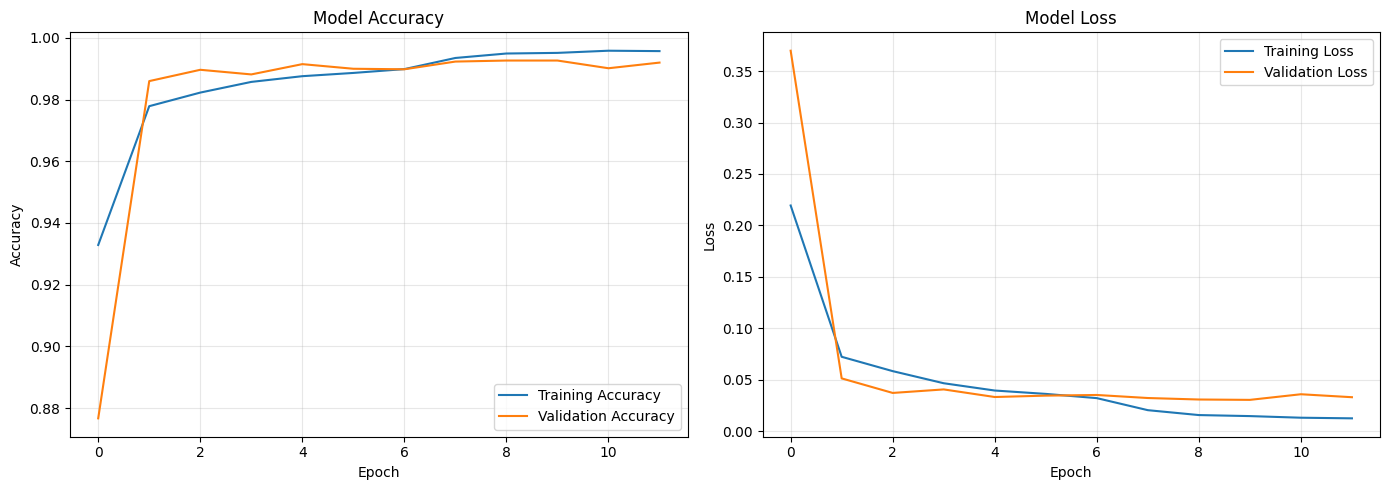


7. Plotting confusion matrix...


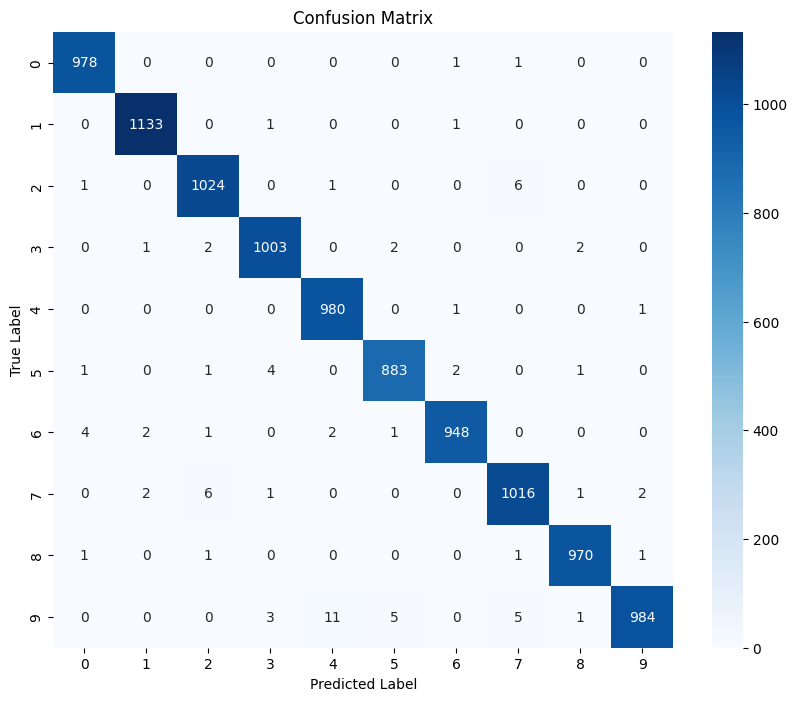


8. Visualizing sample predictions...


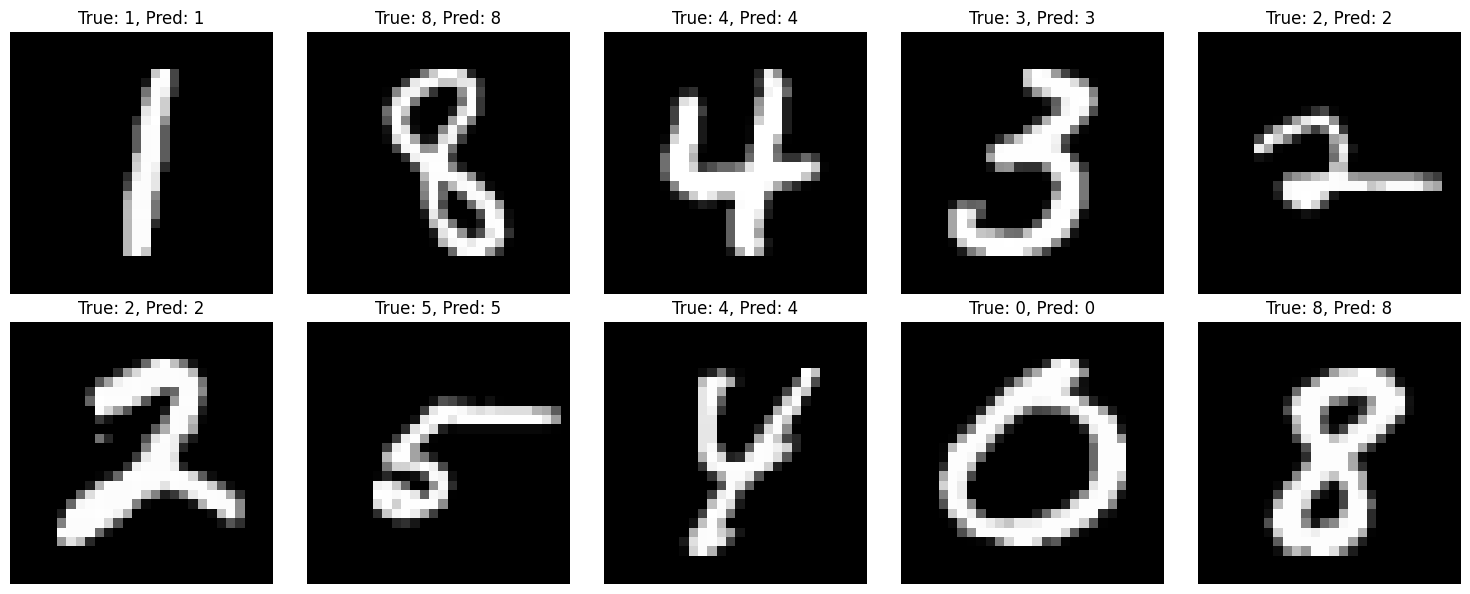


9. Saving model...
Model saved to mnist_cnn_model.keras


In [20]:
def main():
    """
    Main function to demonstrate the CNN class
    """

    print("\nCNN")
    # Load and normalize MNIST data
    print("\n1. Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = normalize_mnist()
    
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    
    # Create CNN instance 
    print("\n2. Creating CNN model")
    cnn = MNIST_CNN(
        conv1_filters=32,    # Within [16,64]
        conv2_filters=64,     # Within [32,128]
        dropout_rate=0.3,     # Within [0.2,0.5]
        learning_rate=0.001
    )
    
    # Prepare data
    print("\n3. Preparing data...")
    cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
    
    # Train the model
    print("\n4. Training model...")
    cnn.train(epochs=15, batch_size=128, verbose=1)
    
    # Evaluate
    print("\n5. Evaluating model...")
    cnn.evaluate()
    
    # Plot training history
    print("\n6. Plotting training history...")
    cnn.plot_training_history()
    
    # Plot confusion matrix
    print("\n7. Plotting confusion matrix...")
    cnn.plot_confusion_matrix()
    
    # Visualize predictions
    print("\n8. Visualizing sample predictions...")
    cnn.visualize_predictions(10)
    
    # Save model
    print("\n9. Saving model...")
    cnn.save_model('mnist_cnn_model.keras')
    

if __name__ == "__main__":
    main()

In [ ]:
class CIFAR10_CNN:
    """
    CNN for CIFAR-10 classification.
    CIFAR-10 images are 32x32x3 (color images)
    - Multiple conv layers with padding (border pixels matter)
    - Batch Normalization
    - Max Pooling
    - Dropout for regularization
    - Dense layers with softmax output
    """
    
    def __init__(self, 
                 architecture_type='default',  # 'default', 'vgg', 'nin', 'residual', 'inception'
                 conv1_filters=32,      
                 conv2_filters=64,       
                 conv3_filters=128,      
                 conv4_filters=256,      
                 dense_units=512,        
                 dropout_rate=0.3,       
                 learning_rate=0.001,
                 experiment_name=None):
        """
        Initialize the CNN model.
        
        param: architecture_type: Type of architecture to build.
        param: conv1_filters: Number of filters in first conv layer.
        param: conv2_filters: Number of filters in second conv layer.
        param: conv3_filters: Number of filters in third conv layer.
        param: conv4_filters: Number of filters in fourth conv layer.
        param: dense_units: Number of units in dense layer.
        param: dropout_rate: Dropout rate for regularization.
        param: learning_rate: Learning rate for optimizer.
        param: experiment_name: Name for this experiment.
        """
        
        self.architecture_type = architecture_type
        self.conv1_filters = conv1_filters
        self.conv2_filters = conv2_filters
        self.conv3_filters = conv3_filters
        self.conv4_filters = conv4_filters
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.experiment_name = experiment_name or f"cifar10_{architecture_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.model = None
        self.history = None
        self.test_accuracy = None
        
        self._build_model()
        
    def _build_model(self):
        """
        Build the CNN architecture based on selected type.
        """
        
        if self.architecture_type == 'default':
            model = self._build_default_architecture()
        elif self.architecture_type == 'vgg':
            model = self._build_vgg_style()
        elif self.architecture_type == 'nin':
            model = self._build_nin_style()
        elif self.architecture_type == 'residual':
            model = self._build_residual_style()
        elif self.architecture_type == 'inception':
            model = self._build_inception_style()
        elif self.architecture_type == 'wide':
            model = self._build_wide_architecture()
        elif self.architecture_type == 'deep':
            model = self._build_deep_architecture()
        else:
            print(f"Unknown architecture type '{self.architecture_type}'. Using default.")
            model = self._build_default_architecture()
        
        # Compile the model
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        self.model = model
        print(f"\n{'='*60}")
        print(f"Architecture Type: {self.architecture_type.upper()}")
        print(f"Experiment: {self.experiment_name}")
        print(f"{'='*60}")
        self.model.summary()
    
    def _build_default_architecture(self):
        """
        Default architecture - 4 conv blocks.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # First Convolutional Block
            layers.Conv2D(self.conv1_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv1_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.2),
            
            # Second Convolutional Block
            layers.Conv2D(self.conv2_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv2_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Third Convolutional Block
            layers.Conv2D(self.conv3_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(self.conv3_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            # Fourth Convolutional Block
            layers.Conv2D(self.conv4_filters, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            
            # Dense layers
            layers.Dense(self.dense_units, use_bias=True),
            layers.ReLU(),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            
            layers.Dense(self.dense_units // 2, use_bias=True),
            layers.ReLU(),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_vgg_style(self):
        """
        VGG-style architecture - multiple convolutions before pooling.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1: 2x conv
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Block 2: 2x conv
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            # Block 3: 3x conv (deeper)
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.5),
            
            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_nin_style(self):
        """
        Network in Network (NiN) style - using 1x1 convolutions.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1
            layers.Conv2D(192, (5, 5), padding='same', activation='relu'),
            layers.Conv2D(160, (1, 1), padding='same', activation='relu'),  # 1x1 conv
            layers.Conv2D(96, (1, 1), padding='same', activation='relu'),   # 1x1 conv
            layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
            layers.Dropout(0.3),
            
            # Block 2
            layers.Conv2D(192, (5, 5), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
            layers.Dropout(0.4),
            
            # Block 3
            layers.Conv2D(192, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(192, (1, 1), padding='same', activation='relu'),
            layers.Conv2D(10, (1, 1), padding='same', activation='relu'),   # Reduce to 10 channels
            
            # Global Average Pooling (instead of Flatten)
            layers.GlobalAveragePooling2D(),
            layers.Activation('softmax')
        ])
        return model
    
    def _build_residual_style(self):
        """
        Residual network style with skip connections.
        """
        inputs = layers.Input(shape=(32, 32, 3))
        
        # Initial convolution
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(0.1)(x)
        
        # Residual Block 1 (no dimension change)
        shortcut = x
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (32, 32, 32)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (16, 16, 32)
        x = layers.Dropout(0.2)(x)
        
        # Residual Block 2 (with dimension change via pooling)
        shortcut = x  # (16, 16, 32)
        shortcut = layers.Conv2D(64, (1, 1), padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
        x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (16, 16, 64) after conv
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (8, 8, 64)
        x = layers.Dropout(0.3)(x)
        
        # Residual Block 3 (with dimension change via pooling)
        shortcut = x  # (8, 8, 64)
        shortcut = layers.Conv2D(128, (1, 1), padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (8, 8, 128)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)  # (4, 4, 128)
        x = layers.Dropout(0.4)(x)
        
        # Residual Block 4 
        shortcut = x  # (4, 4, 128)
        shortcut = layers.Conv2D(256, (1, 1), padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
        x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])  # both (4, 4, 256)
        x = layers.ReLU()(x)
        x = layers.Dropout(0.5)(x)
    
        # Global pooling and output
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(10, activation='softmax')(x)
    
        model = models.Model(inputs, outputs)
        return model
    
    def _build_inception_style(self):
        """
        Inception-style with multiple parallel convolutions.
        """
        inputs = layers.Input(shape=(32, 32, 3))
        
        # Inception Block 1
        tower_1 = layers.Conv2D(32, (1, 1), padding='same', activation='relu')(inputs)
        tower_1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(tower_1)
        
        tower_2 = layers.Conv2D(32, (1, 1), padding='same', activation='relu')(inputs)
        tower_2 = layers.Conv2D(64, (5, 5), padding='same', activation='relu')(tower_2)
        
        tower_3 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(inputs)
        tower_3 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(tower_3)
        
        x = layers.Concatenate()([tower_1, tower_2, tower_3])
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)
        
        # Inception Block 2
        tower_1 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
        tower_1 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(tower_1)
        
        tower_2 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
        tower_2 = layers.Conv2D(128, (5, 5), padding='same', activation='relu')(tower_2)
        
        tower_3 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
        tower_3 = layers.Conv2D(128, (1, 1), padding='same', activation='relu')(tower_3)
        
        x = layers.Concatenate()([tower_1, tower_2, tower_3])
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.4)(x)
        
        # Output
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(10, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        return model
    
    def _build_wide_architecture(self):
        """
        Wide architecture - fewer layers but more filters per layer.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Wide blocks with many filters
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            layers.Conv2D(512, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            
            layers.Dense(1024, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def _build_deep_architecture(self):
        """
        Deep architecture - many layers but moderate filters.
        """
        model = models.Sequential([
            layers.Input(shape=(32, 32, 3)),
            
            # Block 1
            layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.1),
            
            # Block 2
            layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.2),
            
            # Block 3
            layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.2),
            
            # Block 4
            layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.3),
            
            # Block 5
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.3),
            
            # Block 6
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dropout(0.3),
            
            # Block 7
            layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.4),
            
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(self.dropout_rate),
            layers.Dense(10, activation='softmax')
        ])
        return model
    
    def prepare_data(self, x_train, y_train, x_test, y_test, validation_split=0.1):
        """
        Prepare and preprocess the data.
        
        param: x_train: Training images.
        param: y_train: Training labels.
        param: x_test: Test images.
        param: y_test: Test labels.
        param: validation_split: Fraction of training data to use for validation.
        """
        # Ensure data is float32 and reshape if needed
        if len(x_train.shape) == 3:
            x_train = x_train.reshape(-1, 32, 32, 3)
            x_test = x_test.reshape(-1, 32, 32, 3)
        
        # Store data
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.validation_split = validation_split
        
        print(f"\nData prepared:")
        print(f"Training set: {x_train.shape}, {y_train.shape}")
        print(f"Test set: {x_test.shape}, {y_test.shape}")
        print(f"Validation split: {validation_split*100:.0f}%")
        
    def train(self, epochs=50, batch_size=64, verbose=1):
        """
        Train the model.
        
        param: epochs: Number of training epochs.
        param: batch_size: Batch size for training.
        param: verbose: Verbosity level for training output.
        """
        
        # Callbacks for better training
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=verbose
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=verbose
            ),
            callbacks.ModelCheckpoint(
                filepath=f'best_{self.experiment_name}.keras',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=verbose
            )
        ]
        
        print(f"\nStarting training for {epochs} epochs")
        print(f"Batch size: {batch_size}")
        print(f"Dropout rate: {self.dropout_rate}")
        print(f"Learning rate: {self.learning_rate}")
        print("-" * 50)
        
        # Train the model
        self.history = self.model.fit(
            self.x_train, self.y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=self.validation_split,
            callbacks=callbacks_list,
            verbose=verbose
        )
        
        print("\nTraining complete")
        
        # Final evaluation
        train_loss, train_acc = self.model.evaluate(self.x_train, self.y_train, verbose=0)
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        self.test_accuracy = test_acc
        
        print(f"\nFinal Results:")
        print(f"Training accuracy: {train_acc:.4f}")
        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Test loss: {test_loss:.4f}")
        
        return test_acc
    
    def evaluate(self):
        """
        Evaluate the model and show detailed metrics.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Calculate metrics
        test_loss, test_acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        
        print(f"\nTest Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Classification report
        print("\nClassification Report:")
        print("-" * 50)
        target_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']
        print(classification_report(self.y_test, y_pred, target_names=target_names))
        
        return test_loss, test_acc, y_pred
    
    def plot_training_history(self):
        """
        Plot training history.
        """
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot accuracy
        axes[0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title(f'Model Accuracy - {self.architecture_type}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot loss
        axes[1].plot(self.history.history['loss'], label='Training Loss')
        axes[1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[1].set_title(f'Model Loss - {self.architecture_type}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self):
        """
        Plot confusion matrix.
        """
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Compute confusion matrix
        cm = confusion_matrix(self.y_test, y_pred)
        
        # Plot
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['airplane', 'automobile', 'bird', 'cat', 'deer',
                               'dog', 'frog', 'horse', 'ship', 'truck'],
                    yticklabels=['airplane', 'automobile', 'bird', 'cat', 'deer',
                               'dog', 'frog', 'horse', 'ship', 'truck'])
        plt.title(f'Confusion Matrix - {self.architecture_type}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    def visualize_predictions(self, num_samples=10):
        """
        Visualize model predictions on test samples.
        """
        
        # Get random samples
        indices = np.random.choice(len(self.x_test), num_samples, replace=False)
        
        # Get predictions
        y_pred_probs = self.model.predict(self.x_test[indices], verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Class names
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                      'dog', 'frog', 'horse', 'ship', 'truck']
        
        # Plot
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i, idx in enumerate(indices):
            # Denormalize for visualization 
            img = self.x_test[idx].copy()
            # Simple clipping to [0,1] range for display
            img = np.clip(img, 0, 1)
            
            axes[i].imshow(img)
            true_label = class_names[self.y_test[idx][0]] if hasattr(self.y_test[idx], '__len__') else class_names[self.y_test[idx]]
            pred_label = class_names[y_pred[i]]
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
            axes[i].axis('off')
            
            # Color code based on correct/incorrect prediction
            true_val = self.y_test[idx][0] if hasattr(self.y_test[idx], '__len__') else self.y_test[idx]
            if true_val == y_pred[i]:
                axes[i].set_xlabel('Correct', color='green', fontsize=12)
            else:
                axes[i].set_xlabel('Incorrect', color='red', fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath=None):
        """
        Save the trained model.
        """
        if filepath is None:
            filepath = f'{self.experiment_name}.keras'
        
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath):
        """
        Load a saved model.
        """
        self.model = models.load_model(filepath)
        print(f"Model loaded from {filepath}")
        self.model.summary()


# Experiment runner to find best architecture
def run_architecture_experiments(x_train, y_train, x_test, y_test, epochs=30):
    """
    Run experiments with different architectures and find the best one.
    """
    
    architectures = [
        'default',
        'vgg',
        'nin',
        'residual',
        'inception',
        'wide',
        'deep'
    ]
    
    results = []
    
    print("RUNNING ARCHITECTURE EXPERIMENTS")
    
    for arch in architectures:
        print(f"\nTesting Architecture: {arch.upper()}")
        
        # Create model with current architecture
        cnn = CIFAR10_CNN(
            architecture_type=arch,
            conv1_filters=32,
            conv2_filters=64,
            conv3_filters=128,
            conv4_filters=256,
            dense_units=512,
            dropout_rate=0.3,
            learning_rate=0.001,
            experiment_name=f"cifar10_{arch}"
        )
        
        # Prepare data
        cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
        
        # Train model
        test_acc = cnn.train(epochs=epochs, batch_size=64, verbose=1)
        
        # Store results
        results.append({
            'architecture': arch,
            'test_accuracy': test_acc,
            'experiment_name': cnn.experiment_name
        })
        
        # Save model
        cnn.save_model()
        
        print(f"\n{arch.upper()} completed with test accuracy: {test_acc:.4f}")
    
    # Find best architecture
    results_df = pd.DataFrame(results)
    best_result = results_df.loc[results_df['test_accuracy'].idxmax()]
    
    print("EXPERIMENT RESULTS SUMMARY")
    print(results_df.to_string(index=False))
    
    print(f"BEST ARCHITECTURE: {best_result['architecture'].upper()}")
    print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
    print(f"Experiment: {best_result['experiment_name']}")
    
    return results_df, best_result


CIFAR-10 CNN ARCHITECTURE EXPERIMENTS

1. Loading CIFAR-10 dataset...
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
RUNNING ARCHITECTURE EXPERIMENTS

Testing Architecture: RESIDUAL

Architecture Type: RESIDUAL
Experiment: cifar10_residual


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 32, 32,    │        864 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_50[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_41 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 32, 32,    │          0 │ re_lu_41[0][0]    │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 32, 32,    │      9,216 │ dropout_23[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_51[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 32, 32,    │      9,216 │ re_lu_42[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 32, 32,    │          0 │ add_4[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 16, 16,    │          0 │ re_lu_43[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 16, 16,    │          0 │ max_pooling2d_26… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 16, 16,    │     18,432 │ dropout_24[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_44 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 1,497,834 (5.71 MB)

 Trainable params: 1,493,418 (5.70 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_84 (Conv2D)              │ (None, 32, 32, 128)    │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_62 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_63 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_64 (ReLU)                 │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_65 (ReLU)                 │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 8, 8, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_66 (ReLU)                 │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1024)           │       525,31

 Total params: 2,760,074 (10.53 MB)

 Trainable params: 2,755,466 (10.51 MB)

 Non-trainable params: 4,608 (18.00 KB)


Data prepared:
Training set: (50000, 32, 32, 3), (50000, 1)
Test set: (10000, 32, 32, 3), (10000, 1)
Validation split: 10%

Starting training for 50 epochs
Batch size: 64
Dropout rate: 0.3
Learning rate: 0.001
--------------------------------------------------
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.3297 - loss: 2.0434
Epoch 1: val_accuracy improved from None to 0.53160, saving model to best_best_cifar10_wide_final.keras

Epoch 1: finished saving model to best_best_cifar10_wide_final.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 702s 991ms/step - accuracy: 0.4140 - loss: 1.7132 - val_accuracy: 0.5316 - val_loss: 1.3108 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.5554 - loss: 1.2462
Epoch 2: val_accuracy improved from 0.53160 to 0.58400, saving model to best_best_cifar10_wide_final.keras

Epoch 2: finished saving model to best_best_cifar10_wide_final.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 769s 1s/step - accuracy: 0.5773 - los

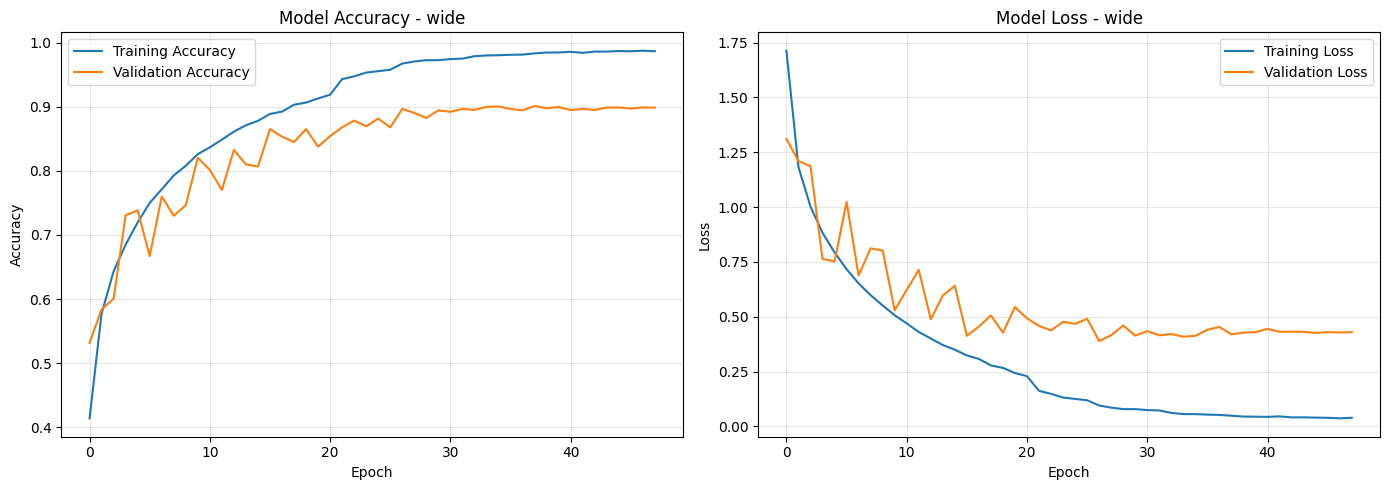

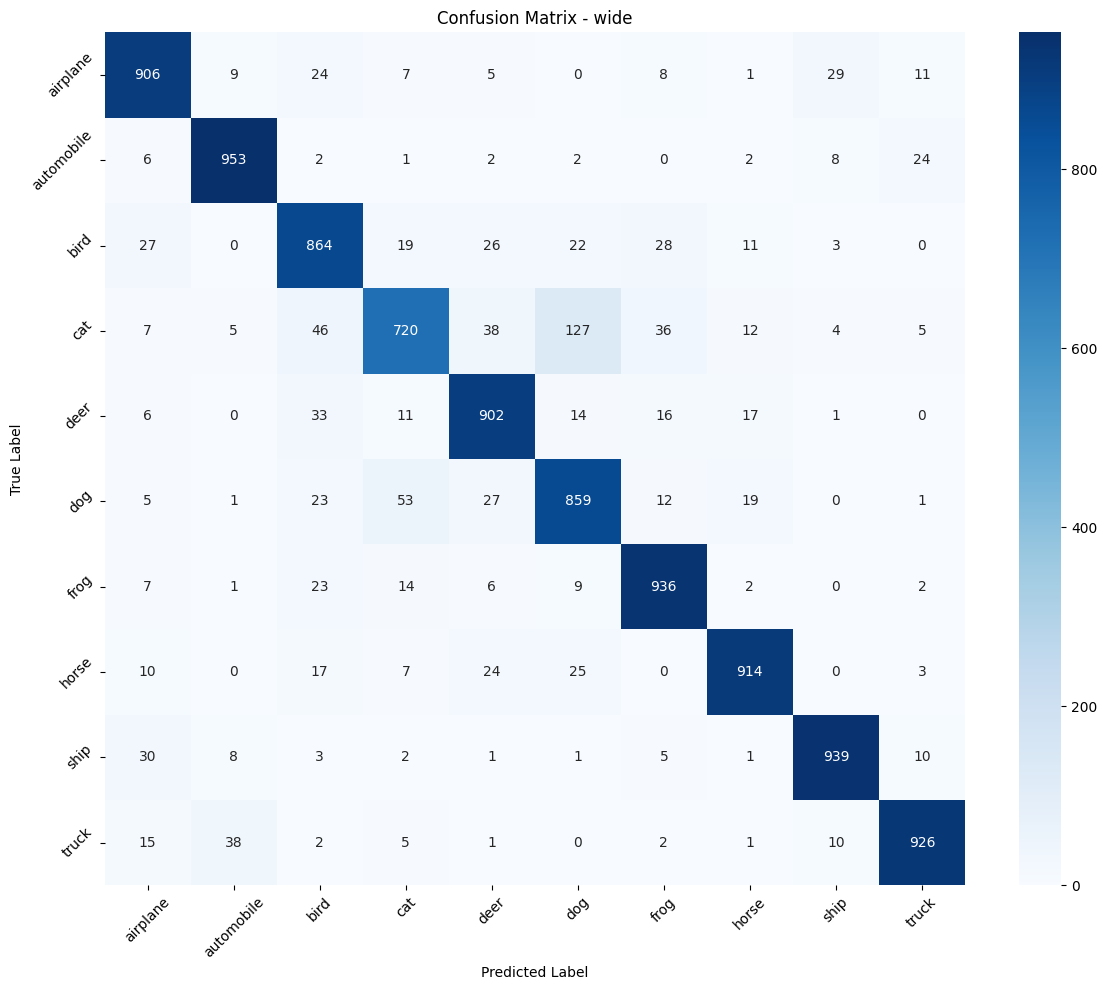

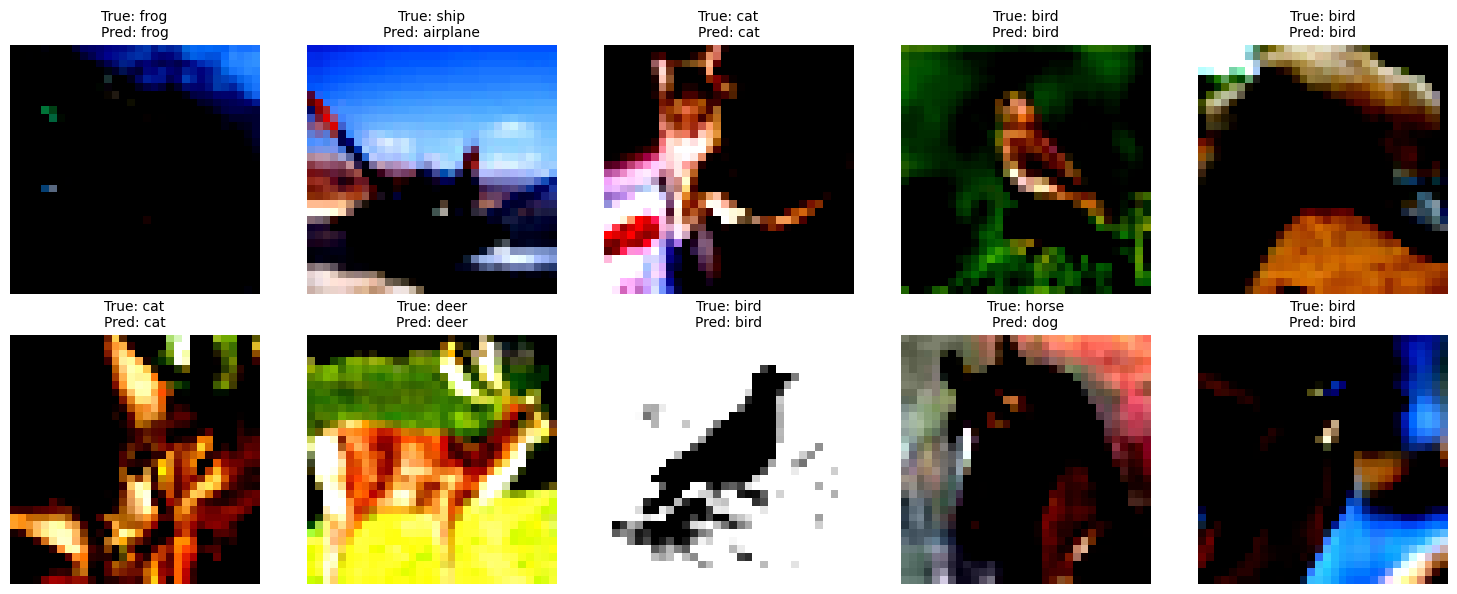

Model saved to best_cifar10_model.keras


In [ ]:
def main():
    """
    Main function forthe CIFAR-10 CNN class with experiments.
    """
    print("CIFAR-10 CNN ARCHITECTURE EXPERIMENTS")
    
    # Load normalized CIFAR-10 data
    print("\n1. Loading CIFAR-10 dataset")
    (x_train, y_train), (x_test, y_test) = normalize_cifar10()
    
    print(f"Training data shape: {x_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    
    # Run experiments with different architectures
    results_df, best_result = run_architecture_experiments(
        x_train, y_train, x_test, y_test, 
        epochs=30  
    )
    
    # Train the best architecture longer for final model
    print(f"TRAINING BEST ARCHITECTURE ({best_result['architecture'].upper()}) FOR FINAL MODEL")
    
    best_cnn = CIFAR10_CNN(
        architecture_type=best_result['architecture'],
        conv1_filters=32,
        conv2_filters=64,
        conv3_filters=128,
        conv4_filters=256,
        dense_units=512,
        dropout_rate=0.3,
        learning_rate=0.001,
        experiment_name=f"best_cifar10_{best_result['architecture']}_final"
    )
    
    best_cnn.prepare_data(x_train, y_train, x_test, y_test, validation_split=0.1)
    best_cnn.train(epochs=50, batch_size=64, verbose=1)
    
    # Final evaluation
    print("FINAL MODEL EVALUATION")
    best_cnn.evaluate()
    
    # Plot results
    best_cnn.plot_training_history()
    best_cnn.plot_confusion_matrix()
    best_cnn.visualize_predictions(10)
    
    # Save final model
    best_cnn.save_model('best_cifar10_model.keras')
    
    return best_cnn, results_df
    


if __name__ == "__main__":
    best_model, results = main()

For the CIFAR10 set we use 7 different architecture types and tests which one performs best. 

Default is a 4 blocks design that uses 2 convolutional layers per block. For each block the filters increase and dropout increases. Global average pool at the end.

VGG uses stacked convolutions before pooling with consistant filter size throughout the block. Deeper in later blocks and uses Flatten() instead of global pooling. Slower as we train more parameters.

NIN uses 1x1 convolutions as small netowkrs. Each 1x1 convolutes each regular convolution and ends with gloabal average pooling. Fewer parameters so faster but is harder to train as underfitting might occurs with smaller datasets.

ResNet skips connections and solves vanishing gradient. Projects shortcuts when dimensions change and can therefore train very deep.

Inception uses multiple parallel convolution paths (1x1, 3x3, 5x5) and uses outputs from different scales. 1x1 reducees dimensionality. Captures features at multiple spatial scales and pools each path in parallel.

Wide uses fewer layers but wider filters. More parameters per layer might cause overfitting but is also able to capture more features per layer.

Deep uses many layers with gradual increase. Heavy dropout throughout with moderate filter sizes.

Again validation split of 10\% of training data.

The wide network got the best validation accuarcy so we rerun the fit for extended epochs. However the accuracy is not as good as for the MNIST dataset due to the RGB colorscale of the CIFAR-10 set which introduces more complexity compared to the greyscale of MNIST. There are also backgrounds and more variation in the CIFAR-10 set, both between different classes but also within different classes which makes the classification task more advanced. Test Accuracy: 0.8919 for the CIFAR-10 test set compared to 0.9919 for the MNIST set.

In [ ]:
class KNN_Classifier:
    """
    k-Nearest neighbours classifier for MNIST and CIFAR-10 datasets.
    Uses Euclidean distance pixel-by-pixel.
    """
    
    def __init__(self, dataset_name='mnist'):
        """
        Initialize the kNN classifier.
        
        param: dataset_name: 'mnist' or 'cifar10'.
        """
        
        self.dataset_name = dataset_name
        self.models = {}  # Store models for different k values
        self.best_k = None
        self.best_model = None
        self.best_val_accuracy = 0
        self.results = {}
    
    def prepare_data(self, x_train, y_train, x_test, y_test, validation_split=0.1):
        """
        Prepare data for kNN classification.
        kNN requires flattening the images into 1D vectors.
        
        param: x_train: Training images (normalized).
        param: y_train: Training labels.
        param: x_test: Test images (normalized).
        param: y_test: Test labels.
        param: validation_split: Fraction of training data to use for validation.
        """
        
        # Flatten the images
        n_train = x_train.shape[0]
        n_test = x_test.shape[0]
        
        self.x_train_flat = x_train.reshape(n_train, -1)
        self.x_test_flat = x_test.reshape(n_test, -1)
        self.y_train = y_train
        self.y_test = y_test
        self.x_train_sub, self.x_val, self.y_train_sub, self.y_val = train_test_split(
            self.x_train_flat, self.y_train, test_size=validation_split, 
            random_state=42, stratify=self.y_train
        )
        
        print(f"\nData prepared:")
        print(f"Training set: {x_train.shape}, {y_train.shape}")
        print(f"Test set: {x_test.shape}, {y_test.shape}")
        print(f"Validation split: {validation_split*100:.0f}%")
        
    def find_best_k(self, k_range=range(1,26), verbose=True):
        """
        Try different k values and find the one with highest validation accuracy.
        
        param: k_range: Range of k values to try.
        param: verbose: Whether to print progress.
        """
        
        print(f"\nFinding best k value for {self.dataset_name.upper()}")
        
        val_accuracies = []
        train_accuracies = []
        training_times = []
        
        for k in k_range:
            start_time = time.time()
            
            knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform', n_jobs=-1)
            
            # Train on training subset
            knn.fit(self.x_train_sub, self.y_train_sub.ravel() if len(self.y_train_sub.shape) > 1 else self.y_train_sub)
            
            train_acc = accuracy_score(self.y_train_sub.ravel() if len(self.y_train_sub.shape) > 1 else self.y_train_sub,knn.predict(self.x_train_sub))
            
            val_acc = accuracy_score(self.y_val.ravel() if len(self.y_val.shape) > 1 else self.y_val, knn.predict(self.x_val))
            
            training_time = time.time() - start_time
            
            val_accuracies.append(val_acc)
            train_accuracies.append(train_acc)
            training_times.append(training_time)
            
            # Store model
            self.models[k] = {
                'model': knn,
                'train_accuracy': train_acc,
                'val_accuracy': val_acc,
                'training_time': training_time
            }
            
            # Track best model
            if val_acc > self.best_val_accuracy:
                self.best_val_accuracy = val_acc
                self.best_k = k
                self.best_model = knn
                
            if verbose and k % 5 == 0:
                print(f"k={k:2d}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Time={training_time:.2f}s")
                
        self.results = {
            'k_values': list(k_range),
            'val_accuracies': val_accuracies,
            'train_accuracies': train_accuracies,
            'training_times': training_times
        }
        
        print(f"\nBest k = {self.best_k} with validation accuracy = {self.best_val_accuracy:.4f}")
        
        return self.best_k, self.best_val_accuracy
    
    
    def evaluate_on_test(self):
        """
        Evaluate the best model on test set.
        """
        
        print(f"\nEvaluating best model (k={self.best_k}) on test set")
        
        start_time = time.time()
        y_pred = self.best_model.predict(self.x_test_flat)
        test_time = time.time() - start_time
        
        # Calculate accuracy
        test_accuracy = accuracy_score(
            self.y_test.ravel() if len(self.y_test.shape) > 1 else self.y_test,
            y_pred
        )
        
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Test Prediction Time: {test_time:.2f}s")
        
        return test_accuracy, y_pred
    
    def plot_k_comparison(self):
        """
        Plot validation accuracy vs k values.
        """
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot accuracies
        axes[0].plot(self.results['k_values'], self.results['train_accuracies'], 
                    'b-', label='Training Accuracy', marker='o')
        axes[0].plot(self.results['k_values'], self.results['val_accuracies'], 
                    'r-', label='Validation Accuracy', marker='s')
        axes[0].axvline(x=self.best_k, color='g', linestyle='--', 
                       label=f'Best k={self.best_k}')
        axes[0].set_xlabel('k (number of neighbours)')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title(f'{self.dataset_name.upper()}: Accuracy vs k')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xticks(self.results['k_values'][::2])
        
        # Plot training time
        axes[1].plot(self.results['k_values'], self.results['training_times'], 
                    'g-', marker='o')
        axes[1].set_xlabel('k (number of neighbours)')
        axes[1].set_ylabel('Training Time (seconds)')
        axes[1].set_title(f'{self.dataset_name.upper()}: Training Time vs k')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xticks(self.results['k_values'][::2])
        
        plt.tight_layout()
        plt.show()
    
    def plot_confusion_matrix(self, y_pred):
        """
        Plot confusion matrix for test predictions.
        """
        if self.dataset_name == 'mnist':
            labels = [str(i) for i in range(10)]
        else:
            labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']
        
        cm = confusion_matrix(
            self.y_test.ravel() if len(self.y_test.shape) > 1 else self.y_test,
            y_pred
        )
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=labels, yticklabels=labels)
        plt.title(f'{self.dataset_name.upper()} kNN Confusion Matrix (k={self.best_k})')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        if self.dataset_name == 'cifar10':
            plt.xticks(rotation=45)
            plt.yticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
def run_knn_experiments():
    """
    Run kNN experiments for both MNIST and CIFAR-10 sets.
    """
    
    (x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = normalize_mnist()
    (x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = normalize_cifar10()
    
    results = {}
    
    print(f"\nMNIST kNN CLASSIFICATION")
    mnist_knn = KNN_Classifier(dataset_name='mnist')
    mnist_knn.prepare_data(
        x_train_mnist, y_train_mnist,
        x_test_mnist, y_test_mnist,
        validation_split=0.1
    )
    
    best_k_mnist, best_val_acc_mnist = mnist_knn.find_best_k(k_range=range(1, 26))
    mnist_knn.plot_k_comparison()
    test_acc_mnist, y_pred_mnist = mnist_knn.evaluate_on_test()
    mnist_knn.plot_confusion_matrix(y_pred_mnist)
    
    results['mnist'] = {
        'best_k': best_k_mnist,
        'val_accuracy': best_val_acc_mnist,
        'test_accuracy': test_acc_mnist
    }
    
    print(f"\nCIFAR-10 kNN CLASSIFICATION")
    
    
    cifar_knn = KNN_Classifier(dataset_name='cifar10')
    cifar_knn.prepare_data(
        x_train_cifar, y_train_cifar,
        x_test_cifar, y_test_cifar,
        validation_split=0.1
    )
    
    best_k_cifar, best_val_acc_cifar = cifar_knn.find_best_k(k_range=range(1, 26))
    cifar_knn.plot_k_comparison()
    test_acc_cifar, y_pred_cifar = cifar_knn.evaluate_on_test()
    cifar_knn.plot_confusion_matrix(y_pred_cifar)
    
    results['cifar10'] = {
        'best_k': best_k_cifar,
        'val_accuracy': best_val_acc_cifar,
        'test_accuracy': test_acc_cifar
    }
    
    return results

MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093

MNIST kNN CLASSIFICATION

Data prepared:
Training set: (60000, 28, 28), (60000,)
Test set: (10000, 28, 28), (10000,)
Validation split: 10%

Finding best k value for MNIST
k= 5: Train Acc=0.9815, Val Acc=0.9683, Time=59.54s
k=10: Train Acc=0.9740, Val Acc=0.9652, Time=60.74s
k=15: Train Acc=0.9698, Val Acc=0.9638, Time=61.38s
k=20: Train Acc=0.9665, Val Acc=0.9597, Time=61.04s
k=25: Train Acc=0.9636, Val Acc=0.9578, Time=59.72s

Best k = 3 with validation accuracy = 0.9713


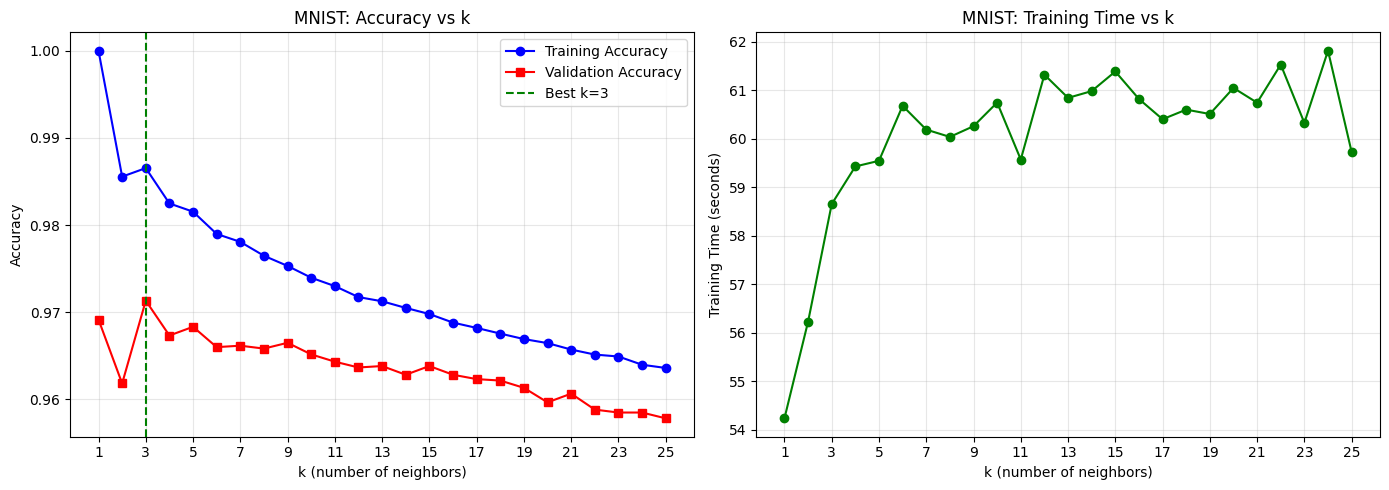


Evaluating best model (k=3) on test set
Test Accuracy: 0.9699
Test Prediction Time: 10.44s


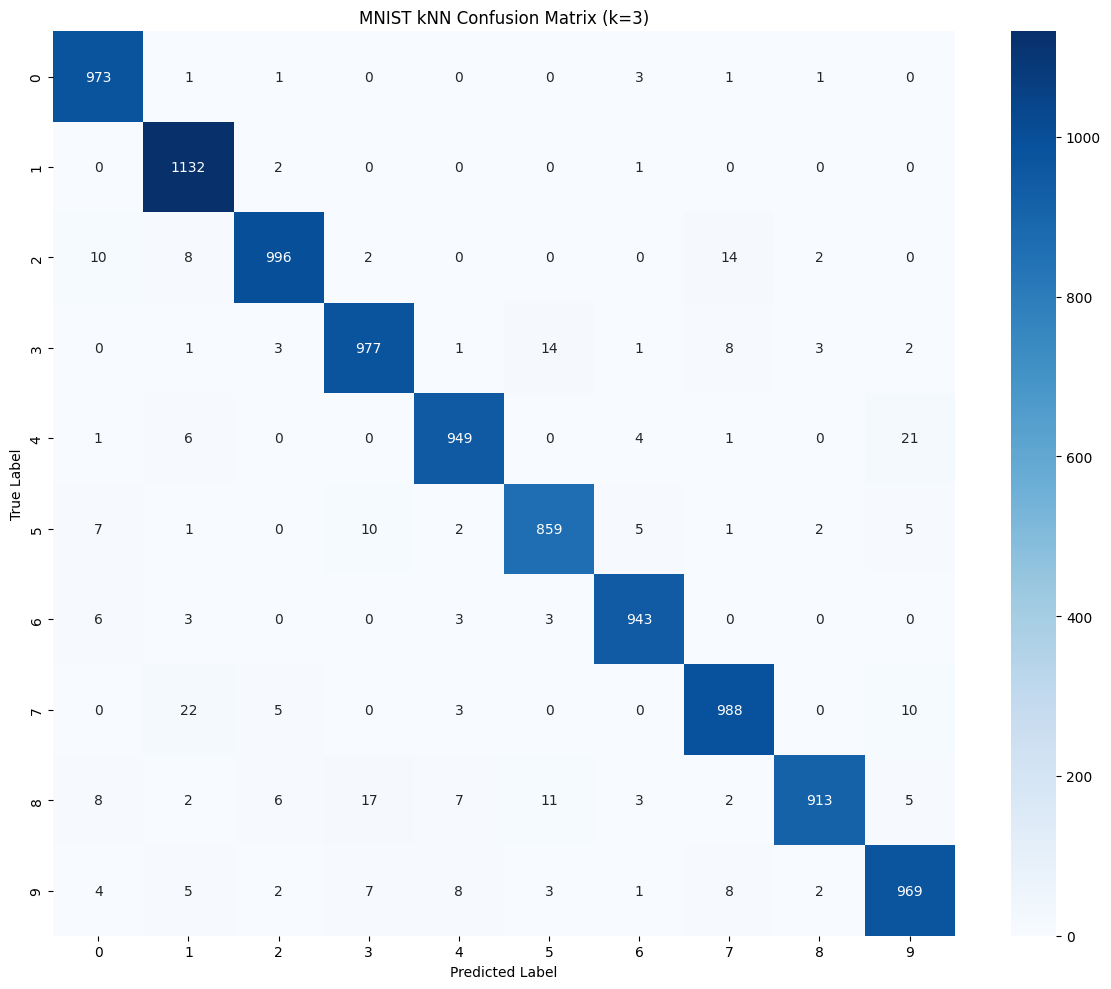


CIFAR-10 kNN CLASSIFICATION

Data prepared:
Training set: (50000, 32, 32, 3), (50000, 1)
Test set: (10000, 32, 32, 3), (10000, 1)
Validation split: 10%

Finding best k value for CIFAR10
k= 5: Train Acc=0.5020, Val Acc=0.3440, Time=156.71s
k=10: Train Acc=0.4272, Val Acc=0.3372, Time=154.78s
k=15: Train Acc=0.3960, Val Acc=0.3332, Time=155.10s
k=20: Train Acc=0.3784, Val Acc=0.3312, Time=154.84s
k=25: Train Acc=0.3662, Val Acc=0.3306, Time=153.68s

Best k = 1 with validation accuracy = 0.3456


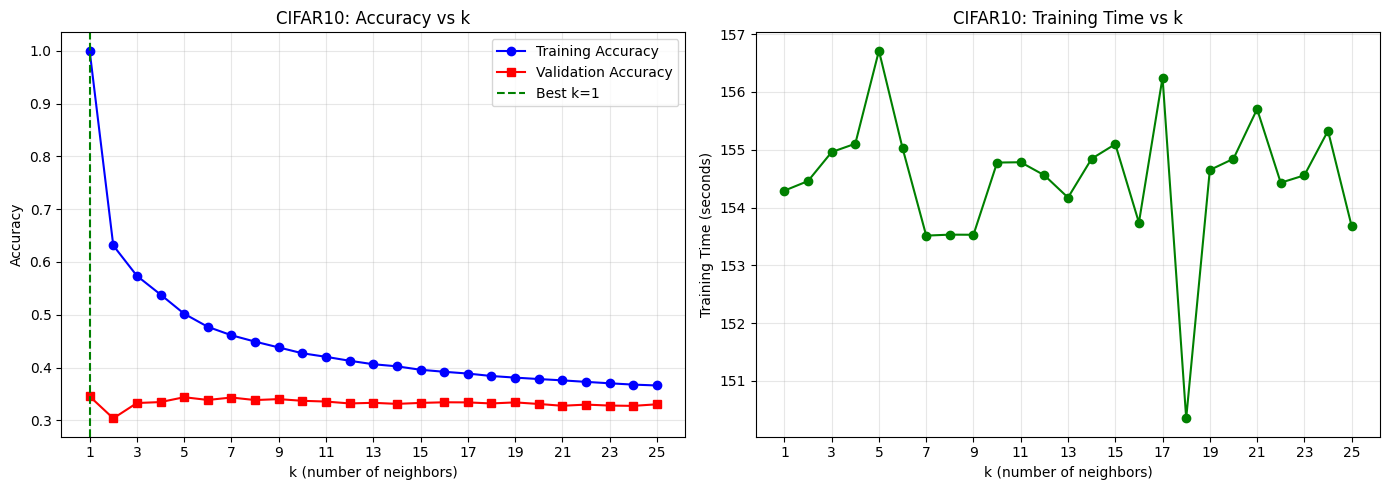


Evaluating best model (k=1) on test set
Test Accuracy: 0.3484
Test Prediction Time: 30.34s


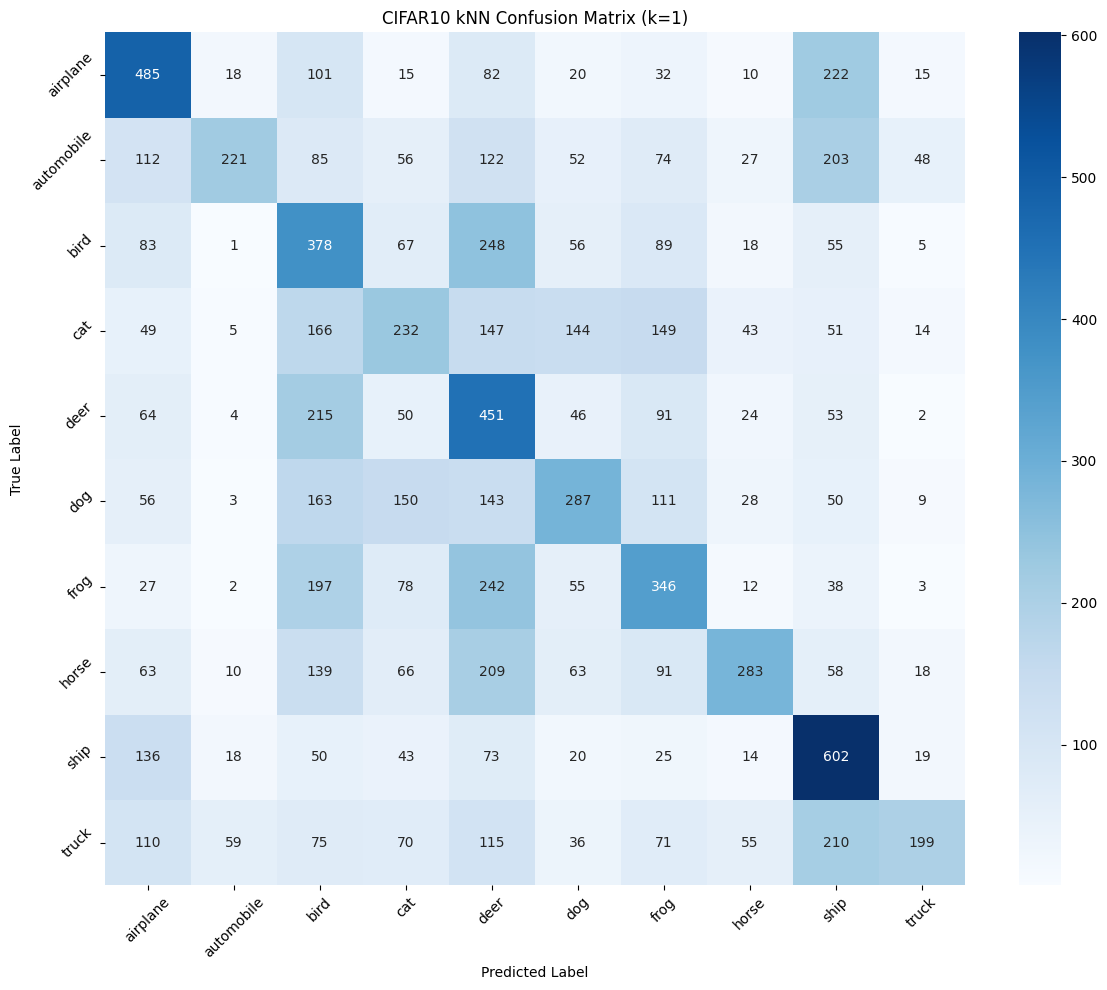

In [38]:
if __name__ == "__main__":
    results = run_knn_experiments()

For the MNIST dataset $k=3$ performs best. It looks at the 3 nearest neighbours to a new point and uses them to make its prediction. MNIST are generally well separated classes with low noise since all variations of the same class are generally very similar. Large k introduces more distant points and might include samples from other digits which causes lower accuracy. 

For CIFAR-10 k=1 performs best. It therefore just uses the closest neighbour to classify a new image. CIFAR-10 is higher dimensions 32x32x3 = 3072 dimensions and the variation in the images is larger than MNIST. The color aspect makes it so that two different images of the same class with different lighting might be very far apart. A dog and a cat with similar lighting might therefore be closer than two dogs with different lighting which makes more close neighbours wrongly classify the image. The data is way noisier and large k smooths too aggressivley. 

Training time per k is very similar for all k.


KNN VISUALIZATION WITH INTERPRETABILITY

1. Loading datasets...
MNIST - Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Original pixel range: [0, 255]
Normalized pixel range: [0.00, 1.00]
CIFAR-10 - Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
Original pixel range: [0, 255]
Original mean: 120.708, std: 64.150
Train data - mean: 0.000001, std: 1.000001
Test data - mean: 0.012809, std: 0.998612
Train data - min: -1.882, max: 2.093
Test data - min: -1.882, max: 2.093

MNIST VISUALIZATION (k=3)
Fitting Nearest neighbour model for MNIST
Training samples: 10000
Feature dimension: 784
Using k = 3
Model fitted successfully!

Showing multiple query images with their neighbour:

Query #1 - Test Image 6252


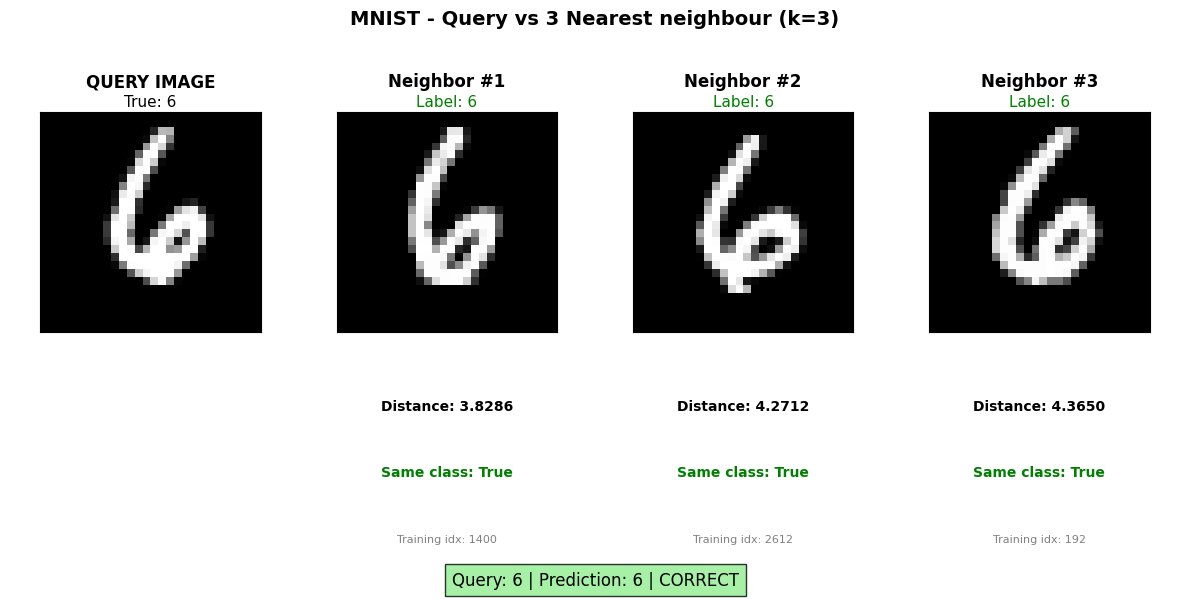


Query #2 - Test Image 4684


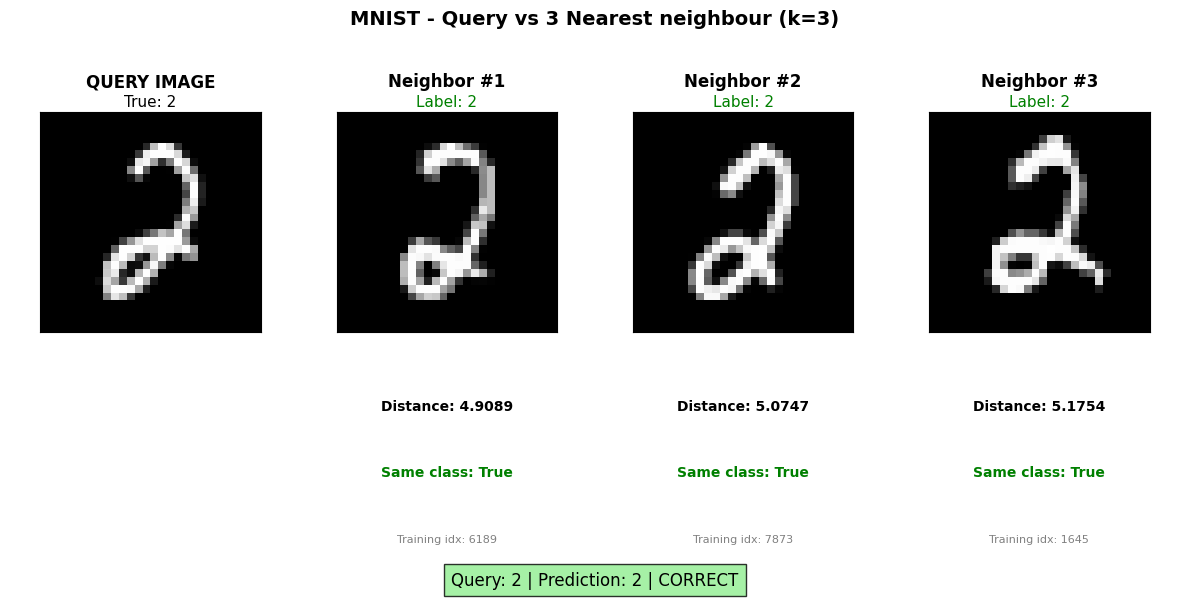


Query #3 - Test Image 1731


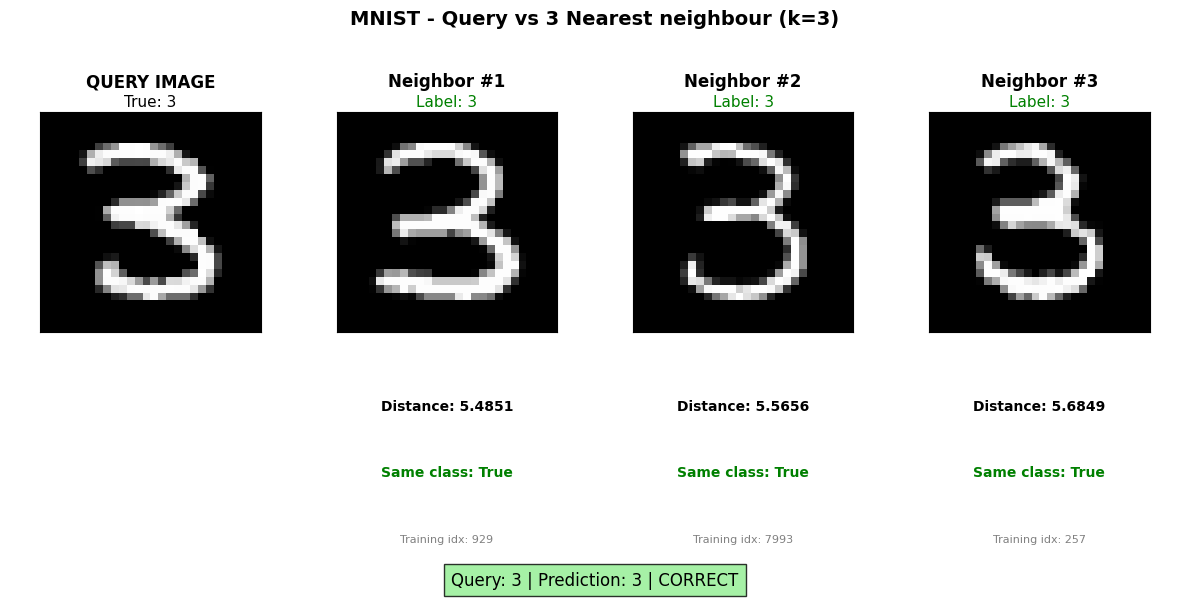


SUMMARY: 3/3 correct (100.0%)

Comparing correct vs incorrect classifications:

Total test samples: 10000
Correct: 9506 (95.1%)
Incorrect: 494 (4.9%)

CORRECT CLASSIFICATIONS (showing 1)

Correct Example #1:


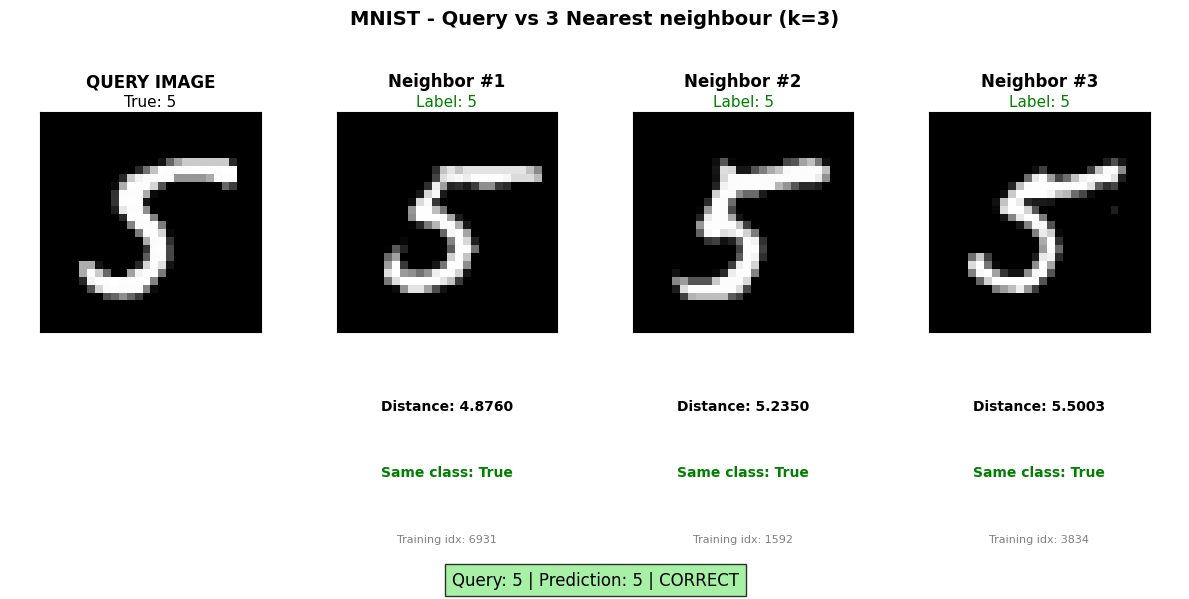


INCORRECT CLASSIFICATIONS (showing 1)

Incorrect Example #1:


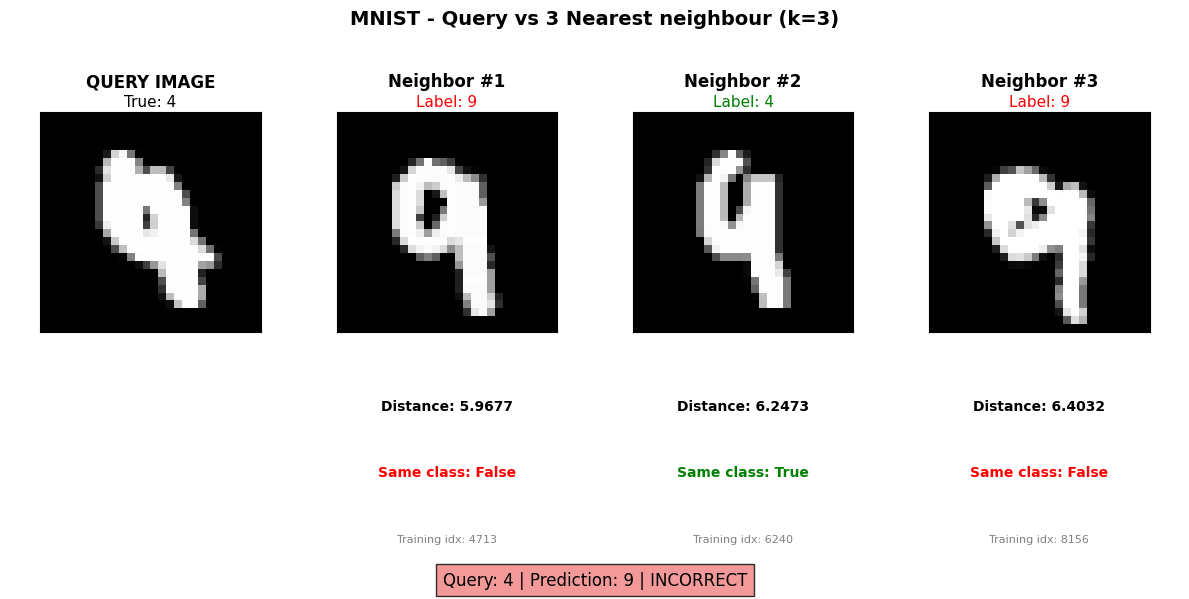


CIFAR-10 VISUALIZATION (k=1)
Fitting Nearest neighbour model for CIFAR10
Training samples: 5000
Feature dimension: 3072
Using k = 1
Model fitted successfully!

Showing multiple query images with their neighbour:

Query #1 - Test Image 6252


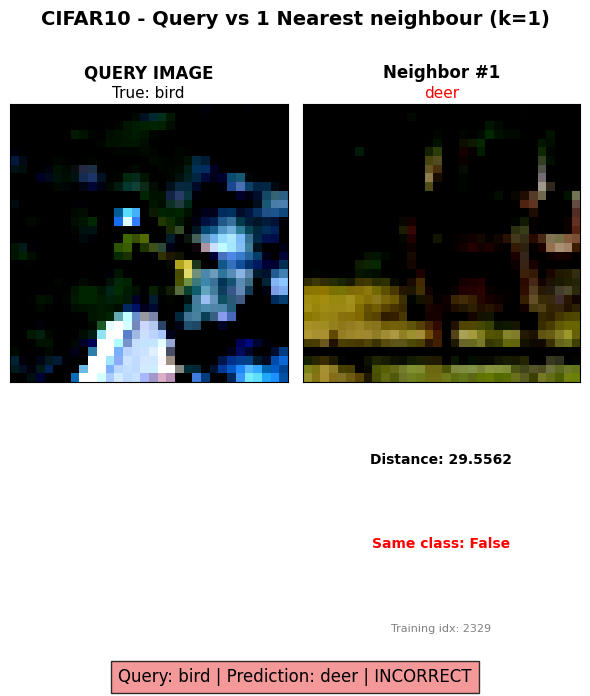


Query #2 - Test Image 4684


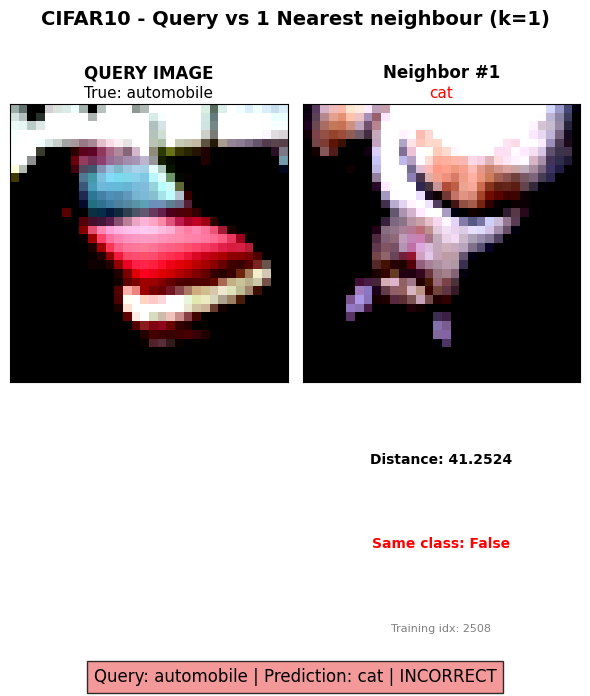


Query #3 - Test Image 1731


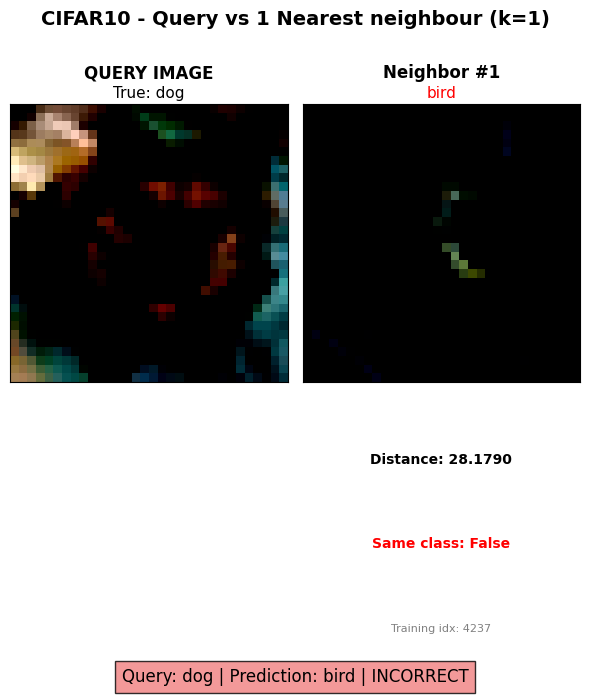


SUMMARY: 0/3 correct (0.0%)

Comparing correct vs incorrect classifications:

Total test samples: 10000
Correct: 2644 (26.4%)
Incorrect: 7356 (73.6%)

CORRECT CLASSIFICATIONS (showing 1)

Correct Example #1:


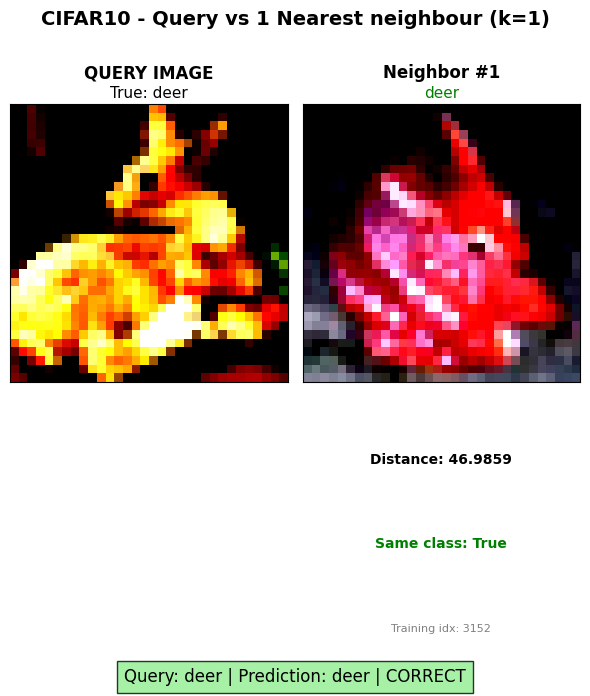


INCORRECT CLASSIFICATIONS (showing 1)

Incorrect Example #1:


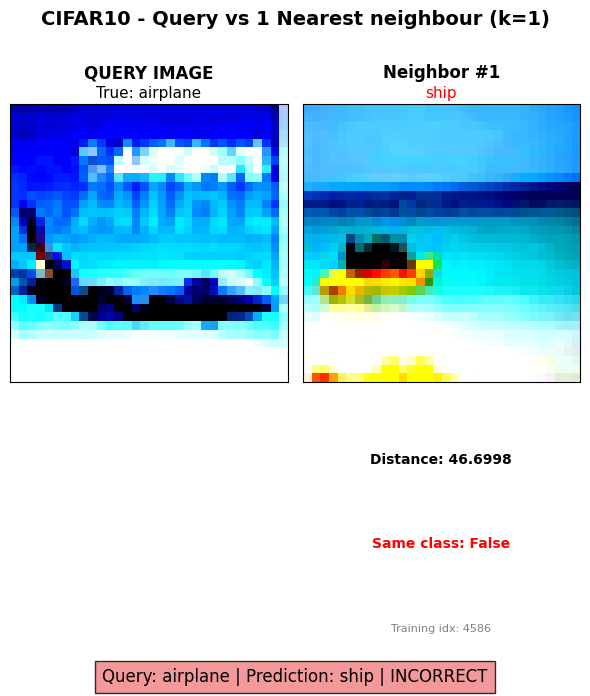

In [47]:
class KNN_Visualizer:
    """
    k-Nearest neighbour visualizer that shows query images alongside their k nearest neighbour.
    Uses pre-determined best k values for interpretability.
    """
    
    def __init__(self, dataset_name='mnist', best_k=None):
        """
        Initialize the KNN visualizer.
        
        param: dataset_name: 'mnist' or 'cifar10'.
        param: best_k: The best k value to use (3 for MNIST, 1 for CIFAR-10).
        """
        self.dataset_name = dataset_name
        self.best_k = best_k
        self.nn_model = None
        self.x_train = None
        self.y_train = None
        self.x_test = None
        self.y_test = None
        
        # Class names for CIFAR-10
        self.cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                             'dog', 'frog', 'horse', 'ship', 'truck']
        
    def fit(self, x_train, y_train, x_test, y_test):
        """
        Fit the nearest neighbour model on training data.
        
        param: x_train: Training images (normalized).
        param: y_train: Training labels.
        param: x_test: Test images (normalized).
        param: y_test: Test labels.
        """
        # Store original images for visualization
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        
        # Flatten images for nearest neighbor search
        n_train = x_train.shape[0]
        self.x_train_flat = x_train.reshape(n_train, -1)
        
        # Fit nearest neighbour model
        print(f"Fitting Nearest neighbour model for {self.dataset_name.upper()}")
        print(f"Training samples: {n_train}")
        print(f"Feature dimension: {self.x_train_flat.shape[1]}")
        print(f"Using k = {self.best_k}")
        
        self.nn_model = NearestNeighbors(
            n_neighbors=self.best_k,
            metric='euclidean',
            algorithm='auto',
            n_jobs=-1
        )
        self.nn_model.fit(self.x_train_flat)
        print("Model fitted successfully!")
        
    def find_neighbour(self, test_idx):
        """
        Find k nearest neighbour for a test image.
        
        param: test_idx: Index of test image.
        returns: distances and indices of nearest neighbour.
        """
        # Get test image
        test_image_flat = self.x_test[test_idx].reshape(1, -1)
        
        # Find nearest neighbour
        distances, indices = self.nn_model.kneighbors(test_image_flat)
        
        return distances[0], indices[0]
    
    def visualize_query_with_neighbour(self, test_idx, save_path=None):
        """
        Visualize a test image alongside its k nearest neighbour.
        
        param: test_idx: Index of test image to visualize
        param: save_path: Optional path to save the figure
        """
        # Find nearest neighbour
        distances, neighbor_indices = self.find_neighbour(test_idx)
        
        # Get true label
        true_label = self.y_test[test_idx]
        if self.dataset_name == 'cifar10':
            true_label = true_label[0]  # CIFAR-10 labels are 2D
        
        # Determine layout based on k
        n_neighbour = len(neighbor_indices)
        
        if self.dataset_name == 'mnist':
            fig, axes = plt.subplots(2, n_neighbour + 1, figsize=(3*(n_neighbour+1), 6))
        else:
            fig, axes = plt.subplots(2, n_neighbour + 1, figsize=(3*(n_neighbour+1), 7))
        
        # Plot test image
        if self.dataset_name == 'mnist':
            axes[0, 0].imshow(self.x_test[test_idx].reshape(28, 28), cmap='gray')
        else:
            # For CIFAR-10, clip for display
            img_display = np.clip(self.x_test[test_idx], 0, 1)
            axes[0, 0].imshow(img_display)
        
        axes[0, 0].set_title('QUERY IMAGE', fontweight='bold', fontsize=12)
        if self.dataset_name == 'mnist':
            axes[0, 0].set_xlabel(f'True: {true_label}', fontsize=11)
        else:
            axes[0, 0].set_xlabel(f'True: {self.cifar_classes[true_label]}', fontsize=11)
        axes[0, 0].xaxis.set_label_position('top')
        axes[0, 0].tick_params(axis='both', which='both', length=0)
        axes[0, 0].set_xticks([])
        axes[0, 0].set_yticks([])
        
        # Plot neighbour
        for i, (neighbor_idx, dist) in enumerate(zip(neighbor_indices, distances)):
            # Get neighbor label
            neighbor_label = self.y_train[neighbor_idx]
            if self.dataset_name == 'cifar10':
                neighbor_label = neighbor_label[0]
            
            # Determine if neighbor has same class as query
            same_class = (neighbor_label == true_label)
            color = 'green' if same_class else 'red'
            
            # Plot neighbor image
            if self.dataset_name == 'mnist':
                axes[0, i+1].imshow(self.x_train[neighbor_idx].reshape(28, 28), cmap='gray')
                label_text = f'Label: {neighbor_label}'
            else:
                img_display = np.clip(self.x_train[neighbor_idx], 0, 1)
                axes[0, i+1].imshow(img_display)
                label_text = f'{self.cifar_classes[neighbor_label]}'
            
            axes[0, i+1].set_title(f'Neighbor #{i+1}', fontweight='bold', fontsize=12)
            axes[0, i+1].set_xlabel(label_text, color=color, fontsize=11)
            axes[0, i+1].xaxis.set_label_position('top')
            axes[0, i+1].tick_params(axis='both', which='both', length=0)
            axes[0, i+1].set_xticks([])
            axes[0, i+1].set_yticks([])
        
        # Add distance information in second row
        for i, (neighbor_idx, dist) in enumerate(zip(neighbor_indices, distances)):
            neighbor_label = self.y_train[neighbor_idx]
            if self.dataset_name == 'cifar10':
                neighbor_label = neighbor_label[0]
            
            same_class = (neighbor_label == true_label)
            color = 'green' if same_class else 'red'
            
            axes[1, i+1].text(0.5, 0.7, f'Distance: {dist:.4f}', 
                             ha='center', fontsize=10, fontweight='bold')
            axes[1, i+1].text(0.5, 0.4, f'Same class: {same_class}', 
                             ha='center', fontsize=10, color=color, fontweight='bold')
            axes[1, i+1].text(0.5, 0.1, f'Training idx: {neighbor_idx}', 
                             ha='center', fontsize=8, color='gray')
            axes[1, i+1].axis('off')
        
        # Empty plot for alignment
        axes[1, 0].axis('off')
        
        # Overall title
        prediction = np.bincount([self.y_train[idx][0] if self.dataset_name == 'cifar10' else self.y_train[idx] 
                                  for idx in neighbor_indices]).argmax()
        correct = (prediction == true_label)
        
        if self.dataset_name == 'mnist':
            title = f'{self.dataset_name.upper()} - Query vs {self.best_k} Nearest neighbour (k={self.best_k})'
            result_text = f'Query: {true_label} | Prediction: {prediction} | {"CORRECT" if correct else "INCORRECT"}'
        else:
            title = f'{self.dataset_name.upper()} - Query vs {self.best_k} Nearest neighbour (k={self.best_k})'
            result_text = f'Query: {self.cifar_classes[true_label]} | Prediction: {self.cifar_classes[prediction]} | {"CORRECT" if correct else "INCORRECT"}'
        
        fig.suptitle(title, fontsize=14, fontweight='bold')
        plt.figtext(0.5, 0.02, result_text, ha='center', fontsize=12, 
                   bbox={'facecolor': 'lightgreen' if correct else 'lightcoral', 
                         'alpha': 0.8, 'pad': 5})
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        
        plt.show()
        
        return prediction, correct
    
    def visualize_multiple_queries(self, num_queries=5, random_seed=None):
        """
        Visualize multiple random test queries with their neighbour.
        
        param: num_queries: Number of random test images to visualize.
        param: random_seed: Random seed for reproducibility.
        """
        if random_seed:
            np.random.seed(random_seed)
        
        # Select random test indices
        test_indices = np.random.choice(len(self.x_test), num_queries, replace=False)
        
        results = []
        for i, idx in enumerate(test_indices):
            print(f"\n{'='*60}")
            print(f"Query #{i+1} - Test Image {idx}")
            print(f"{'='*60}")
            pred, correct = self.visualize_query_with_neighbour(idx)
            results.append({
                'test_idx': idx,
                'prediction': pred,
                'correct': correct
            })
        
        # Summary
        correct_count = sum([r['correct'] for r in results])
        print(f"\n{'='*60}")
        print(f"SUMMARY: {correct_count}/{num_queries} correct ({correct_count/num_queries*100:.1f}%)")
        print(f"{'='*60}")
        
        return results
    
    def compare_correct_vs_incorrect(self, num_examples=2):
        """
        Show examples of both correct and incorrect classifications.
        """
        # Get predictions for all test images
        all_preds = []
        all_true = []
        
        for i in range(len(self.x_test)):
            neighbour = self.find_neighbour(i)[1]
            neighbor_labels = [self.y_train[idx][0] if self.dataset_name == 'cifar10' else self.y_train[idx] 
                              for idx in neighbour]
            pred = np.bincount(neighbor_labels).argmax()
            true = self.y_test[i][0] if self.dataset_name == 'cifar10' else self.y_test[i]
            all_preds.append(pred)
            all_true.append(true)
        
        all_preds = np.array(all_preds)
        all_true = np.array(all_true)
        
        # Find correct and incorrect indices
        correct_indices = np.where(all_preds == all_true)[0]
        incorrect_indices = np.where(all_preds != all_true)[0]
        
        print(f"\n{'='*60}")
        print(f"Total test samples: {len(self.x_test)}")
        print(f"Correct: {len(correct_indices)} ({len(correct_indices)/len(self.x_test)*100:.1f}%)")
        print(f"Incorrect: {len(incorrect_indices)} ({len(incorrect_indices)/len(self.x_test)*100:.1f}%)")
        print(f"{'='*60}")
        
        # Show correct examples
        if len(correct_indices) > 0:
            print(f"\nCORRECT CLASSIFICATIONS (showing {min(num_examples, len(correct_indices))})")
            correct_samples = np.random.choice(correct_indices, min(num_examples, len(correct_indices)), replace=False)
            for i, idx in enumerate(correct_samples):
                print(f"\nCorrect Example #{i+1}:")
                self.visualize_query_with_neighbour(idx)
        
        # Show incorrect examples
        if len(incorrect_indices) > 0:
            print(f"\nINCORRECT CLASSIFICATIONS (showing {min(num_examples, len(incorrect_indices))})")
            incorrect_samples = np.random.choice(incorrect_indices, min(num_examples, len(incorrect_indices)), replace=False)
            for i, idx in enumerate(incorrect_samples):
                print(f"\nIncorrect Example #{i+1}:")
                self.visualize_query_with_neighbour(idx)


def run_knn_visualization():
    """
    Run KNN visualization for both datasets using best k values.
    """
    
    print("\nKNN VISUALIZATION WITH INTERPRETABILITY")
   
    
    # Load datasets
    print("\n1. Loading datasets...")
    (x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = normalize_mnist()
    (x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = normalize_cifar10()
    
    # Best k values from your experiments
    MNIST_BEST_K = 3
    CIFAR10_BEST_K = 1
    
    results = {}
    
    # ===== MNIST Visualization =====
    print("\nMNIST VISUALIZATION (k=3)")
    
    
    mnist_viz = KNN_Visualizer(dataset_name='mnist', best_k=MNIST_BEST_K)
    
    # Use subset of training data for faster computation (optional)
    # For MNIST, full 60k is fine, but you can use subset for speed
    n_train_mnist = 10000  # Use 10k training samples for faster neighbor search
    indices = np.random.choice(len(x_train_mnist), n_train_mnist, replace=False)
    
    mnist_viz.fit(
        x_train_mnist[indices], y_train_mnist[indices],
        x_test_mnist, y_test_mnist
    )
    
    # Show multiple examples
    print("\nShowing multiple query images with their neighbour:")
    mnist_results = mnist_viz.visualize_multiple_queries(num_queries=3, random_seed=42)
    
    # Show comparison of correct vs incorrect
    print("\nComparing correct vs incorrect classifications:")
    mnist_viz.compare_correct_vs_incorrect(num_examples=1)
    
    # ===== CIFAR-10 Visualization =====
    print("\n" + "="*60)
    print("CIFAR-10 VISUALIZATION (k=1)")
    print("="*60)
    
    cifar_viz = KNN_Visualizer(dataset_name='cifar10', best_k=CIFAR10_BEST_K)
    
    # Use subset of training data for CIFAR-10
    n_train_cifar = 5000  # Use 5k training samples
    indices = np.random.choice(len(x_train_cifar), n_train_cifar, replace=False)
    
    cifar_viz.fit(
        x_train_cifar[indices], y_train_cifar[indices],
        x_test_cifar, y_test_cifar
    )
    
    # Show multiple examples
    print("\nShowing multiple query images with their neighbour:")
    cifar_results = cifar_viz.visualize_multiple_queries(num_queries=3, random_seed=42)
    
    # Show comparison of correct vs incorrect
    print("\nComparing correct vs incorrect classifications:")
    cifar_viz.compare_correct_vs_incorrect(num_examples=1)
    
    return mnist_viz, cifar_viz


# Simple function to visualize a specific test image
def visualize_single_example(dataset='mnist', test_idx=None):
    """
    Visualize a single test image with its neighbour.
    
    param: dataset: 'mnist' or 'cifar10'.
    param: test_idx: Index of test image to visualize (random if None).
    """
    # Load dataset
    if dataset == 'mnist':
        (x_train, y_train), (x_test, y_test) = normalize_mnist()
        best_k = 3
        n_train = 10000
    else:
        (x_train, y_train), (x_test, y_test) = normalize_cifar10()
        best_k = 1
        n_train = 10000
    
    # Use subset
    indices = np.random.choice(len(x_train), n_train, replace=False)
    x_train_subset = x_train[indices]
    y_train_subset = y_train[indices]
    
    # Create visualizer
    viz = KNN_Visualizer(dataset_name=dataset, best_k=best_k)
    viz.fit(x_train_subset, y_train_subset, x_test, y_test)
    
    # Choose test image
    if test_idx is None:
        test_idx = np.random.randint(len(x_test))
    
    # Visualize
    print(f"\nVisualizing test image #{test_idx}")
    viz.visualize_query_with_neighbour(test_idx)
    
    return viz


if __name__ == "__main__":
    # Run full visualization
    mnist_viz, cifar_viz = run_knn_visualization()
    
    # Or visualize a single example
    # visualize_single_example('mnist', test_idx=42)
    # visualize_single_example('cifar10', test_idx=100)

For the MNIST set we can see that the distances are smaller in comparison to CIFAR-10. The incorrect classification displayed is an edge case where the variation of the 4 is very close to the 9 class. The 4 in question is very noisy and out of shape which is why it more resembles a nine than other 4:s. When looking at the query images and neighbours for the CIFAR-10 set the backgrounds for all pairs are similar which is why they are classified wrongly. For the correct classification of the deer we have pretty similar shape of the deer and similar backgrounds so the classifier is able to make the correct prediction.